In [28]:
import torch.nn as nn
class LinearProbe(nn.Module):
    def __init__(self, input_dim: int, num_classes: int):
        super().__init__()
        self.linear = nn.Linear(input_dim, num_classes)
    
    def forward(self, x):
        return self.linear(x)

In [29]:
import torch
checkpoint = torch.load("/pasteur2/u/yuhuiz/yiming/experiments/src/results/CLIP_20250130_000703/best_model.pth", weights_only=False)
checkpoint['model_state_dict']

OrderedDict([('linear.weight',
              tensor([[ 0.0428,  0.0462, -0.0832,  ..., -0.0012, -0.0615,  0.0234],
                      [ 0.0304,  0.0712,  0.1197,  ..., -0.0387, -0.0014,  0.0132],
                      [ 0.0633, -0.0446,  0.0975,  ...,  0.0884,  0.0422,  0.0197],
                      ...,
                      [ 0.0114, -0.0866,  0.1197,  ..., -0.0028, -0.1656, -0.0255],
                      [ 0.1705,  0.1169,  0.0322,  ..., -0.0516, -0.0149, -0.0335],
                      [-0.0171, -0.0610,  0.0548,  ...,  0.0370,  0.0457, -0.0889]],
                     device='cuda:0')),
             ('linear.bias',
              tensor([-4.3156e-02, -9.8157e-02, -1.7936e-02, -2.2125e-02, -1.7007e-02,
                       2.5237e-02, -2.4390e-02, -9.1721e-03,  8.6499e-03, -1.2348e-01,
                      -3.4979e-02, -1.1372e-01, -6.6109e-02, -7.8137e-02, -1.3202e-01,
                      -7.4018e-02, -8.1262e-02, -5.4363e-02, -3.0070e-02, -1.0139e-01,
                    

In [16]:
linear = LinearProbe(768, 1000)
linear.load_state_dict(checkpoint['model_state_dict'])

<All keys matched successfully>

<KeysViewHDF5 ['last_hidden_cls', 'paths', 'targets']>
[b'/pasteur/u/yuhuiz/data/ImageNet/imagenet/train/n01440764/n01440764_10211.JPEG'
 b'/pasteur/u/yuhuiz/data/ImageNet/imagenet/train/n01440764/n01440764_10218.JPEG'
 b'/pasteur/u/yuhuiz/data/ImageNet/imagenet/train/n01440764/n01440764_10227.JPEG'
 b'/pasteur/u/yuhuiz/data/ImageNet/imagenet/train/n01440764/n01440764_1024.JPEG'
 b'/pasteur/u/yuhuiz/data/ImageNet/imagenet/train/n01440764/n01440764_10251.JPEG'
 b'/pasteur/u/yuhuiz/data/ImageNet/imagenet/train/n01440764/n01440764_10254.JPEG'
 b'/pasteur/u/yuhuiz/data/ImageNet/imagenet/train/n01440764/n01440764_10281.JPEG'
 b'/pasteur/u/yuhuiz/data/ImageNet/imagenet/train/n01440764/n01440764_10290.JPEG'
 b'/pasteur/u/yuhuiz/data/ImageNet/imagenet/train/n01440764/n01440764_10293.JPEG'
 b'/pasteur/u/yuhuiz/data/ImageNet/imagenet/train/n01440764/n01440764_10307.JPEG']


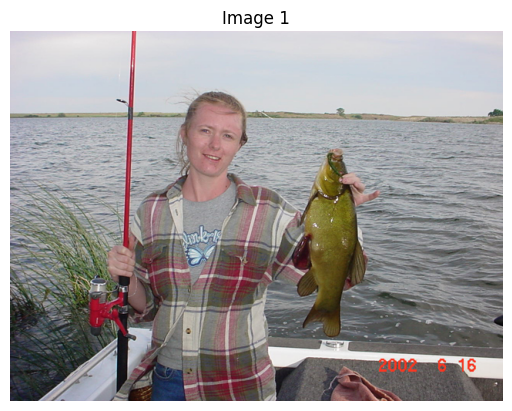

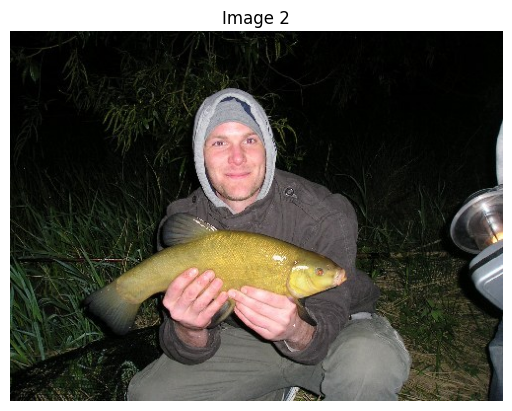

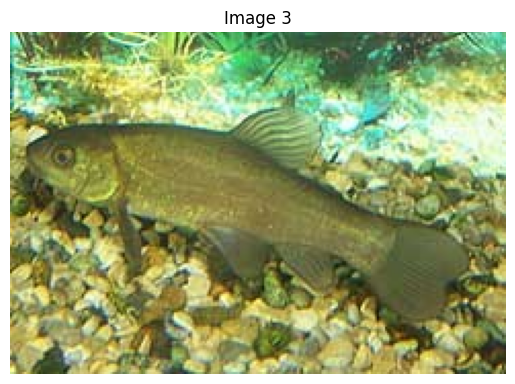

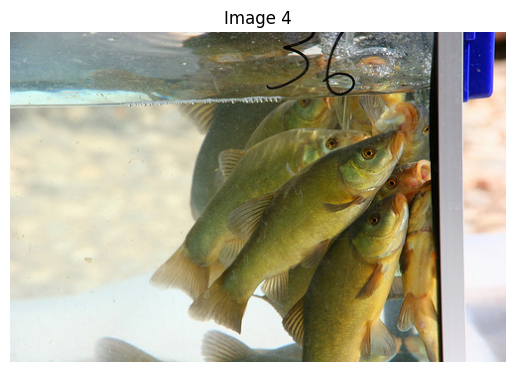

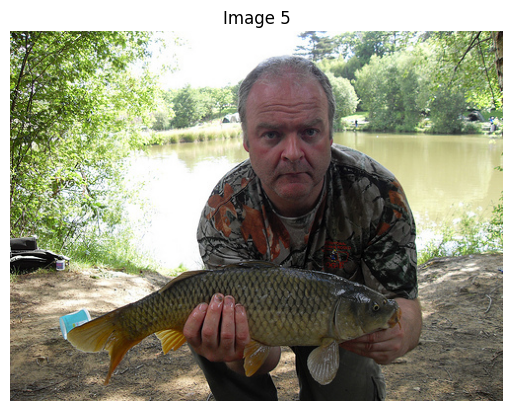

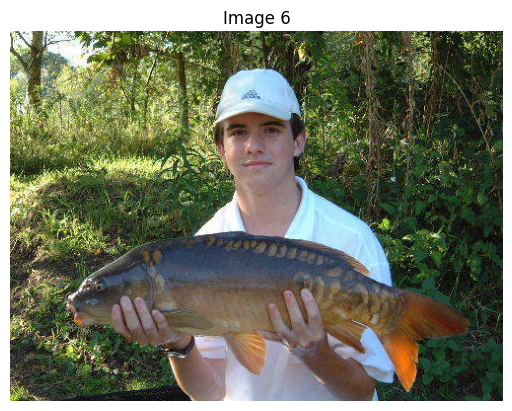

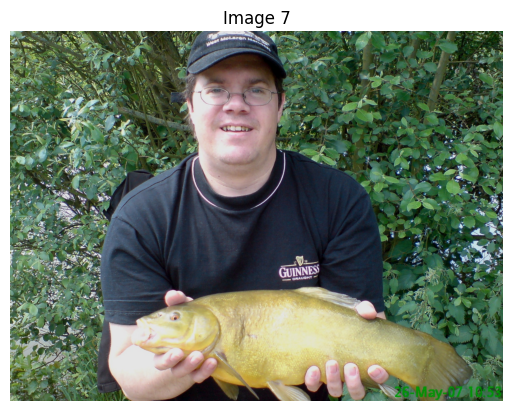

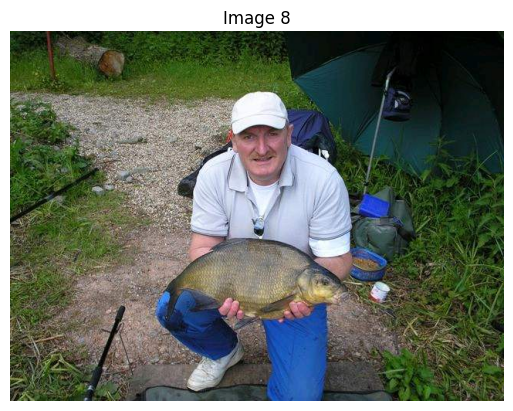

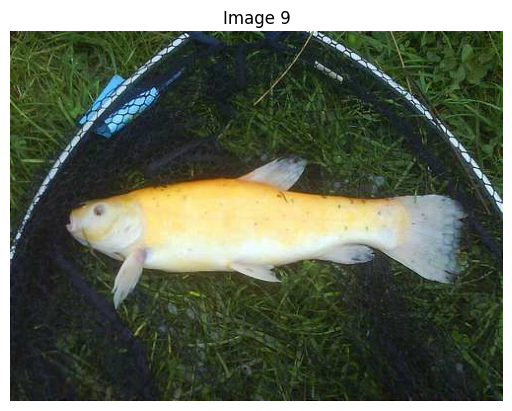

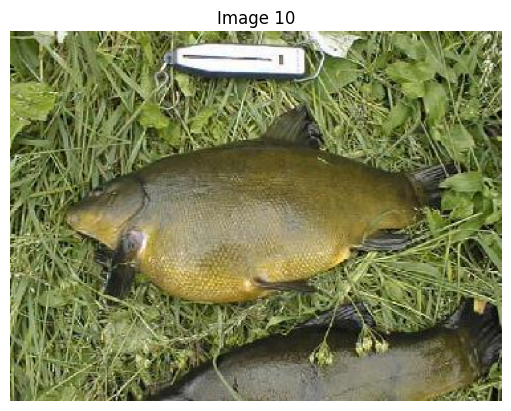

In [30]:
import h5py
import matplotlib.pyplot as plt
from PIL import Image
h5_file_path = "/pasteur2/u/yuhuiz/yiming/experiments/src/cached_features/imagenet/mae_train_features.h5"

with h5py.File(h5_file_path, 'r') as f:
    print(f.keys())  # 查看有哪些键
    cls = f['last_hidden_cls'][20:30]
    cls = torch.FloatTensor(cls)
    paths = f['paths'][20:30]  # 读取前5个路径
    targets = f['targets'][20:30]
    print(paths)

# for i, path in enumerate(cls):
#     answer = linear(path)
#     print(torch.argmax(answer))
#     print(f"answer: {targets[i]}")

# 显示前 5 张图片
for i, path in enumerate(paths):
    img = Image.open(path)

    plt.figure()
    plt.imshow(img)
    plt.axis("off")  # 隐藏坐标轴
    plt.title(f"Image {i+1}")
    plt.show()


<KeysViewHDF5 ['last_hidden_cls', 'paths', 'targets']>
[b'/pasteur/u/yuhuiz/data/ImageNet/imagenet/val/n01440764/ILSVRC2012_val_00000293.JPEG'
 b'/pasteur/u/yuhuiz/data/ImageNet/imagenet/val/n01440764/ILSVRC2012_val_00002138.JPEG'
 b'/pasteur/u/yuhuiz/data/ImageNet/imagenet/val/n01440764/ILSVRC2012_val_00003014.JPEG'
 b'/pasteur/u/yuhuiz/data/ImageNet/imagenet/val/n01440764/ILSVRC2012_val_00006697.JPEG'
 b'/pasteur/u/yuhuiz/data/ImageNet/imagenet/val/n01440764/ILSVRC2012_val_00007197.JPEG']
[0 0 0 0 0 0 0 0 0 0]


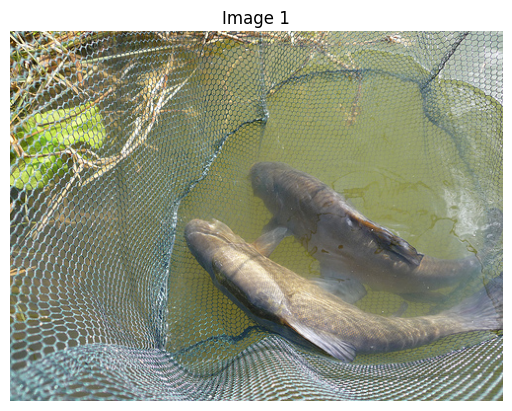

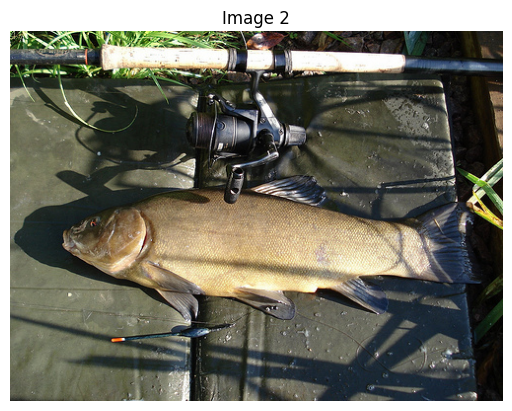

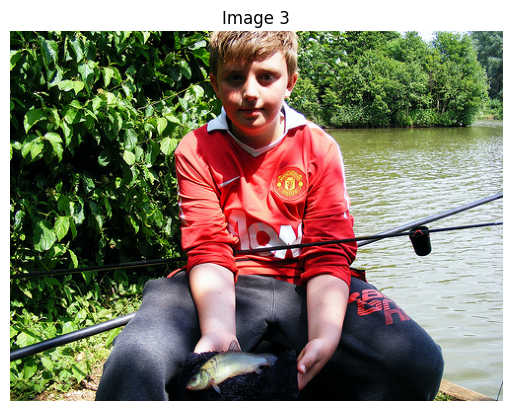

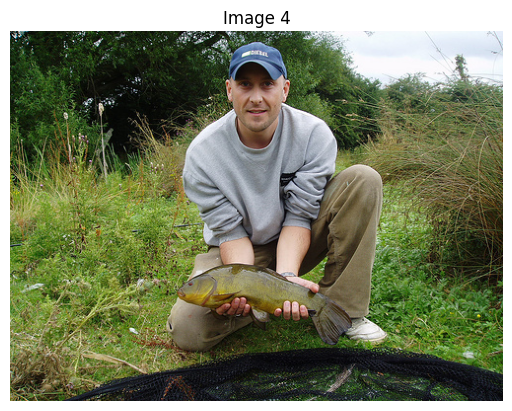

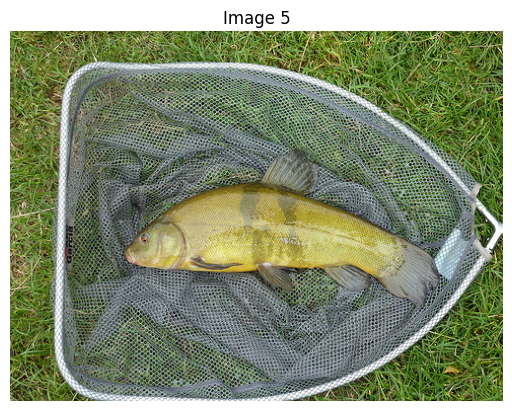

In [8]:
h5_file_path = "/pasteur2/u/yuhuiz/yiming/experiments/src/cached_features/imagenet/clip_val_features.h5"

with h5py.File(h5_file_path, 'r') as f:
    print(f.keys())  # 查看有哪些键
    paths = f['paths'][:5]  # 读取前5个路径
    print(paths)
    print(f['targets'][:10])

# 显示前 5 张图片
for i, path in enumerate(paths):
    img = Image.open(path)

    plt.figure()
    plt.imshow(img)
    plt.axis("off")  # 隐藏坐标轴
    plt.title(f"Image {i+1}")
    plt.show()


In [30]:
import os
import shutil
from pathlib import Path

def get_imagenet_folders(imagenet_val_path):
    """
    获取ImageNet验证集中的文件夹名称列表，按字母顺序排序
    
    Args:
        imagenet_val_path: ImageNet验证集文件夹路径
        
    Returns:
        有序的文件夹名称列表
    """
    folders = []
    for folder in sorted(os.listdir(imagenet_val_path)):
        if os.path.isdir(os.path.join(imagenet_val_path, folder)):
            folders.append(folder)
    return folders

def rename_folders(imagenetv2_path, imagenet_val_path):
    """
    将ImageNetV2中的数字文件夹重命名为对应的ImageNet验证集文件夹名
    
    Args:
        imagenetv2_path: ImageNetV2数据集路径
        imagenet_val_path: ImageNet验证集路径
    """
    # 获取ImageNet验证集中的文件夹名称
    imagenet_folders = get_imagenet_folders(imagenet_val_path)
    
    # 获取ImageNetV2中的数字文件夹名并按数字大小排序
    imagenetv2_folders = []
    for folder in os.listdir(imagenetv2_path):
        if os.path.isdir(os.path.join(imagenetv2_path, folder)) and folder.isdigit():
            imagenetv2_folders.append(folder)
    imagenetv2_folders.sort(key=int)  # 按数字大小排序
    
    # 确保文件夹数量匹配
    if len(imagenetv2_folders) != len(imagenet_folders):
        raise ValueError(f"文件夹数量不匹配: ImageNetV2有{len(imagenetv2_folders)}个文件夹, "
                        f"而ImageNet验证集有{len(imagenet_folders)}个文件夹")
    
    # 创建映射关系：数字文件夹 -> ImageNet文件夹名
    folder_mapping = dict(zip(imagenetv2_folders, imagenet_folders))
    
    # 执行重命名
    print("开始重命名文件夹...")
    for old_name, new_name in folder_mapping.items():
        old_path = os.path.join(imagenetv2_path, old_name)
        new_path = os.path.join(imagenetv2_path, new_name)
        
        # 如果目标文件夹已存在，使用临时名称
        if os.path.exists(new_path):
            temp_path = new_path + "_temp"
            os.rename(old_path, temp_path)
            os.rename(temp_path, new_path)
        else:
            os.rename(old_path, new_path)
            
        print(f"已重命名: {old_name} -> {new_name}")
    
    print("重命名完成!")

if __name__ == "__main__":
    # 设置路径
    imagenetv2_path = "/pasteur/u/yuhuiz/data/ImageNet/imagenet/val"  # 修改为实际的ImageNetV2路径
    imagenet_val_path = "/pasteur/u/yuhuiz/data/ImageNet/imagenet/train"  # 修改为实际的ImageNet验证集路径

    try:
        rename_folders(imagenetv2_path, imagenet_val_path)
    except Exception as e:
        print(f"发生错误: {str(e)}")

开始重命名文件夹...
已重命名: 0 -> n01440764
已重命名: 1 -> n01443537
已重命名: 2 -> n01484850
已重命名: 3 -> n01491361
已重命名: 4 -> n01494475
已重命名: 5 -> n01496331
已重命名: 6 -> n01498041
已重命名: 7 -> n01514668
已重命名: 8 -> n01514859
已重命名: 9 -> n01518878
已重命名: 10 -> n01530575
已重命名: 11 -> n01531178
已重命名: 12 -> n01532829
已重命名: 13 -> n01534433
已重命名: 14 -> n01537544
已重命名: 15 -> n01558993
已重命名: 16 -> n01560419
已重命名: 17 -> n01580077
已重命名: 18 -> n01582220
已重命名: 19 -> n01592084
已重命名: 20 -> n01601694
已重命名: 21 -> n01608432
已重命名: 22 -> n01614925
已重命名: 23 -> n01616318
已重命名: 24 -> n01622779
已重命名: 25 -> n01629819
已重命名: 26 -> n01630670
已重命名: 27 -> n01631663
已重命名: 28 -> n01632458
已重命名: 29 -> n01632777
已重命名: 30 -> n01641577
已重命名: 31 -> n01644373
已重命名: 32 -> n01644900
已重命名: 33 -> n01664065
已重命名: 34 -> n01665541
已重命名: 35 -> n01667114
已重命名: 36 -> n01667778
已重命名: 37 -> n01669191
已重命名: 38 -> n01675722
已重命名: 39 -> n01677366
已重命名: 40 -> n01682714
已重命名: 41 -> n01685808
已重命名: 42 -> n01687978
已重命名: 43 -> n01688243
已重命名: 44 -> n01689811
已重命名: 45

In [7]:
import torch
model = torch.load('/pasteur2/u/yuhuiz/yiming/FastSSL/outputs/webdataset_mae_base/checkpoint.pth')
for key in model['model']:
    print(key)

/tmp/user/19662/ipykernel_448474/3283978477.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load('/pasteur2/u/yuhuiz/yiming/FastSSL/outputs/webdataset_mae_

cls_token
pos_embed
mask_token
decoder_pos_embed
patch_embed.proj.weight
patch_embed.proj.bias
blocks.0.norm1.weight
blocks.0.norm1.bias
blocks.0.attn.qkv.weight
blocks.0.attn.qkv.bias
blocks.0.attn.proj.weight
blocks.0.attn.proj.bias
blocks.0.norm2.weight
blocks.0.norm2.bias
blocks.0.mlp.fc1.weight
blocks.0.mlp.fc1.bias
blocks.0.mlp.fc2.weight
blocks.0.mlp.fc2.bias
blocks.1.norm1.weight
blocks.1.norm1.bias
blocks.1.attn.qkv.weight
blocks.1.attn.qkv.bias
blocks.1.attn.proj.weight
blocks.1.attn.proj.bias
blocks.1.norm2.weight
blocks.1.norm2.bias
blocks.1.mlp.fc1.weight
blocks.1.mlp.fc1.bias
blocks.1.mlp.fc2.weight
blocks.1.mlp.fc2.bias
blocks.2.norm1.weight
blocks.2.norm1.bias
blocks.2.attn.qkv.weight
blocks.2.attn.qkv.bias
blocks.2.attn.proj.weight
blocks.2.attn.proj.bias
blocks.2.norm2.weight
blocks.2.norm2.bias
blocks.2.mlp.fc1.weight
blocks.2.mlp.fc1.bias
blocks.2.mlp.fc2.weight
blocks.2.mlp.fc2.bias
blocks.3.norm1.weight
blocks.3.norm1.bias
blocks.3.attn.qkv.weight
blocks.3.attn.qk

In [10]:
from transformers import AutoModel
model = AutoModel.from_pretrained('facebook/vit-mae-base')
for key in model.state_dict():
    print(key)

embeddings.cls_token
embeddings.position_embeddings
embeddings.patch_embeddings.projection.weight
embeddings.patch_embeddings.projection.bias
encoder.layer.0.attention.attention.query.weight
encoder.layer.0.attention.attention.query.bias
encoder.layer.0.attention.attention.key.weight
encoder.layer.0.attention.attention.key.bias
encoder.layer.0.attention.attention.value.weight
encoder.layer.0.attention.attention.value.bias
encoder.layer.0.attention.output.dense.weight
encoder.layer.0.attention.output.dense.bias
encoder.layer.0.intermediate.dense.weight
encoder.layer.0.intermediate.dense.bias
encoder.layer.0.output.dense.weight
encoder.layer.0.output.dense.bias
encoder.layer.0.layernorm_before.weight
encoder.layer.0.layernorm_before.bias
encoder.layer.0.layernorm_after.weight
encoder.layer.0.layernorm_after.bias
encoder.layer.1.attention.attention.query.weight
encoder.layer.1.attention.attention.query.bias
encoder.layer.1.attention.attention.key.weight
encoder.layer.1.attention.attention

In [9]:
from transformers import AutoModel
model = AutoModel.from_pretrained('facebook/dino-vitb16')
for key in model.state_dict():
    print(key)

Some weights of ViTModel were not initialized from the model checkpoint at facebook/dino-vitb16 and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


embeddings.cls_token
embeddings.position_embeddings
embeddings.patch_embeddings.projection.weight
embeddings.patch_embeddings.projection.bias
encoder.layer.0.attention.attention.query.weight
encoder.layer.0.attention.attention.query.bias
encoder.layer.0.attention.attention.key.weight
encoder.layer.0.attention.attention.key.bias
encoder.layer.0.attention.attention.value.weight
encoder.layer.0.attention.attention.value.bias
encoder.layer.0.attention.output.dense.weight
encoder.layer.0.attention.output.dense.bias
encoder.layer.0.intermediate.dense.weight
encoder.layer.0.intermediate.dense.bias
encoder.layer.0.output.dense.weight
encoder.layer.0.output.dense.bias
encoder.layer.0.layernorm_before.weight
encoder.layer.0.layernorm_before.bias
encoder.layer.0.layernorm_after.weight
encoder.layer.0.layernorm_after.bias
encoder.layer.1.attention.attention.query.weight
encoder.layer.1.attention.attention.query.bias
encoder.layer.1.attention.attention.key.weight
encoder.layer.1.attention.attention

In [12]:
import torch
from transformers import AutoModel
import os

def convert_mae_to_vit(mae_state_dict):
    """将MAE的权重转换为ViT格式"""
    vit_state_dict = {}

    # 1. 基础嵌入层
    vit_state_dict['embeddings.cls_token'] = mae_state_dict['cls_token']
    vit_state_dict['embeddings.position_embeddings'] = mae_state_dict['pos_embed']
    vit_state_dict['embeddings.patch_embeddings.projection.weight'] = mae_state_dict['patch_embed.proj.weight']
    vit_state_dict['embeddings.patch_embeddings.projection.bias'] = mae_state_dict['patch_embed.proj.bias']

    # 2. 处理encoder层
    for i in range(12):
        # 拆分qkv权重和偏置
        qkv_weight = mae_state_dict[f'blocks.{i}.attn.qkv.weight']
        qkv_bias = mae_state_dict[f'blocks.{i}.attn.qkv.bias']

        # ViT-base的hidden size是768
        hidden_size = 768
        qkv_weight = qkv_weight.reshape(3, hidden_size, hidden_size)
        qkv_bias = qkv_bias.reshape(3, hidden_size)

        # Attention权重
        prefix = f'encoder.layer.{i}'
        vit_state_dict[f'{prefix}.attention.attention.query.weight'] = qkv_weight[0]
        vit_state_dict[f'{prefix}.attention.attention.key.weight'] = qkv_weight[1]
        vit_state_dict[f'{prefix}.attention.attention.value.weight'] = qkv_weight[2]

        # Attention偏置
        vit_state_dict[f'{prefix}.attention.attention.query.bias'] = qkv_bias[0]
        vit_state_dict[f'{prefix}.attention.attention.key.bias'] = qkv_bias[1]
        vit_state_dict[f'{prefix}.attention.attention.value.bias'] = qkv_bias[2]

        # 输出投影
        vit_state_dict[f'{prefix}.attention.output.dense.weight'] = mae_state_dict[f'blocks.{i}.attn.proj.weight']
        vit_state_dict[f'{prefix}.attention.output.dense.bias'] = mae_state_dict[f'blocks.{i}.attn.proj.bias']

        # MLP层
        vit_state_dict[f'{prefix}.intermediate.dense.weight'] = mae_state_dict[f'blocks.{i}.mlp.fc1.weight']
        vit_state_dict[f'{prefix}.intermediate.dense.bias'] = mae_state_dict[f'blocks.{i}.mlp.fc1.bias']
        vit_state_dict[f'{prefix}.output.dense.weight'] = mae_state_dict[f'blocks.{i}.mlp.fc2.weight']
        vit_state_dict[f'{prefix}.output.dense.bias'] = mae_state_dict[f'blocks.{i}.mlp.fc2.bias']

        # Layer Norms
        vit_state_dict[f'{prefix}.layernorm_before.weight'] = mae_state_dict[f'blocks.{i}.norm1.weight']
        vit_state_dict[f'{prefix}.layernorm_before.bias'] = mae_state_dict[f'blocks.{i}.norm1.bias']
        vit_state_dict[f'{prefix}.layernorm_after.weight'] = mae_state_dict[f'blocks.{i}.norm2.weight']
        vit_state_dict[f'{prefix}.layernorm_after.bias'] = mae_state_dict[f'blocks.{i}.norm2.bias']

    # 3. 最终的Layer Norm
    vit_state_dict['layernorm.weight'] = mae_state_dict['norm.weight']
    vit_state_dict['layernorm.bias'] = mae_state_dict['norm.bias']

    return vit_state_dict

def verify_state_dict(converted_dict, target_model):
    """验证转换后的权重与目标模型的形状是否匹配"""
    print("\nVerifying state dict shapes...")

    target_dict = target_model.state_dict()
    all_match = True

    # 检查所有键是否存在并比较shape
    for key in target_dict.keys():
        if key not in converted_dict:
            print(f"Missing key in converted dict: {key}")
            all_match = False
            continue

        if converted_dict[key].shape != target_dict[key].shape:
            print(f"Shape mismatch for {key}:")
            print(f"  Converted: {converted_dict[key].shape}")
            print(f"  Target: {target_dict[key].shape}")
            all_match = False

    # 检查是否有多余的键
    for key in converted_dict.keys():
        if key not in target_dict:
            print(f"Extra key in converted dict: {key}")
            all_match = False

    if all_match:
        print("✓ All shapes match successfully!")
    return all_match

def main(mae_checkpoint_path, output_dir):
    # 创建输出目录
    os.makedirs(output_dir, exist_ok=True)

    # 加载MAE checkpoint
    print("Loading MAE checkpoint...")
    mae_ckpt = torch.load(mae_checkpoint_path)
    mae_state_dict = mae_ckpt['model']

    # 转换权重
    print("Converting weights...")
    vit_state_dict = convert_mae_to_vit(mae_state_dict)

    # 加载目标模型进行验证
    print("Loading target model for verification...")
    target_model = AutoModel.from_pretrained('facebook/vit-mae-base')

    # 验证转换后的权重
    is_valid = verify_state_dict(vit_state_dict, target_model)

    if is_valid:
        # 保存转换后的权重
        output_path = os.path.join(output_dir, 'pytorch_model.bin')
        torch.save(vit_state_dict, output_path)
        print(f"\nSuccessfully saved converted weights to {output_path}")
    else:
        print("\nWarning: Shape verification failed. Please check the conversion process.")

    # 打印一些统计信息
    print("\nState dict statistics:")
    print(f"Number of parameters in converted dict: {len(vit_state_dict)}")
    print(f"Number of parameters in target model: {len(target_model.state_dict())}")

if __name__ == "__main__":
    # 设置路径
    mae_checkpoint = '/pasteur2/u/yuhuiz/yiming/FastSSL/outputs/webdataset_mae_base/checkpoint-5.pth'
    output_directory = '/pasteur2/u/yuhuiz/yiming/mae_datacomp'  # 你可以修改为你想要的输出路径

    main(mae_checkpoint, output_directory)

# Created/Modified files during execution:
print(os.path.join(output_directory, 'pytorch_model.bin'))

Loading MAE checkpoint...


/tmp/user/19662/ipykernel_448474/484678885.py:95: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  mae_ckpt = torch.load(mae_checkpoint_path)


Converting weights...
Loading target model for verification...

Verifying state dict shapes...
✓ All shapes match successfully!

Successfully saved converted weights to /pasteur2/u/yuhuiz/yiming/mae_datacomp/pytorch_model.bin

State dict statistics:
Number of parameters in converted dict: 198
Number of parameters in target model: 198
/pasteur2/u/yuhuiz/yiming/mae_datacomp/pytorch_model.bin


In [11]:
from transformers import AutoModel
model = AutoModel.from_pretrained('facebook/vit-mae-base')
for key in model.state_dict():
    print(key)

embeddings.cls_token
embeddings.position_embeddings
embeddings.patch_embeddings.projection.weight
embeddings.patch_embeddings.projection.bias
encoder.layer.0.attention.attention.query.weight
encoder.layer.0.attention.attention.query.bias
encoder.layer.0.attention.attention.key.weight
encoder.layer.0.attention.attention.key.bias
encoder.layer.0.attention.attention.value.weight
encoder.layer.0.attention.attention.value.bias
encoder.layer.0.attention.output.dense.weight
encoder.layer.0.attention.output.dense.bias
encoder.layer.0.intermediate.dense.weight
encoder.layer.0.intermediate.dense.bias
encoder.layer.0.output.dense.weight
encoder.layer.0.output.dense.bias
encoder.layer.0.layernorm_before.weight
encoder.layer.0.layernorm_before.bias
encoder.layer.0.layernorm_after.weight
encoder.layer.0.layernorm_after.bias
encoder.layer.1.attention.attention.query.weight
encoder.layer.1.attention.attention.query.bias
encoder.layer.1.attention.attention.key.weight
encoder.layer.1.attention.attention

In [26]:
from transformers import AutoModel
import torch

# 创建模型时设置mask_ratio=0
model = AutoModel.from_pretrained('facebook/vit-mae-base', mask_ratio=0.0)

# 输入图片
outputs = model(torch.randn(1, 3, 224, 224))
print(outputs.last_hidden_state[:, 0, :])  # 应该输出 [1, 197, 768]

tensor([[ 7.3708e-02, -3.6286e-02, -3.8323e-02, -3.2745e-02, -4.5439e-01,
         -2.0054e+00,  5.1578e-02, -2.6127e-02,  1.1221e-01,  2.6866e-01,
          1.8908e-01,  4.8030e-02,  1.7992e-01, -4.6556e-01, -3.4653e-02,
         -2.1983e-01,  2.9234e-02,  4.3686e-01,  1.2013e-02,  6.5240e-02,
         -2.5367e-01, -1.1065e-01, -2.6644e-01,  1.0497e-01, -7.0854e-02,
         -2.9376e-02,  7.2370e-02, -5.1912e-02, -1.3740e-01, -2.2051e-02,
          3.4982e-01, -2.4075e-01, -6.1952e-01,  2.5200e-01, -7.3997e-02,
          1.8077e-01, -2.1127e-01, -2.1671e-01,  2.1833e-01,  1.7756e-01,
          3.2802e-02,  1.2314e-01, -5.8816e-02,  5.0068e-02, -1.3201e-01,
          3.1311e-02, -3.1119e-01,  2.3794e-01, -3.4033e-01,  6.0513e-02,
          1.3110e-01, -4.2435e-02,  2.2174e-01, -1.8419e-01, -6.8179e-01,
         -1.6652e-01,  2.6702e-02, -3.0785e-01, -1.3758e-01,  1.2901e-01,
         -1.4150e-01,  1.2476e-01,  1.9000e-01, -2.4848e-01, -2.6473e-01,
         -5.0622e-02, -2.8041e-01, -4.

In [20]:
import torch
model.eval()
output = model(torch.randn(1, 3, 224, 224))
for key, value in output.items():
    print(key)
    print(value.shape)

TypeError: ViTMAEModel.forward() got an unexpected keyword argument 'mask_ratio'

In [8]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from transformers import AutoModel, AutoConfig
from torch.optim import Adam

# 数据集路径
data_path = "/pasteur/u/yuhuiz/data/ImageNet/imagenet"
train_dir = os.path.join(data_path, "train")
val_dir = os.path.join(data_path, "val")

# 数据增强和预处理
transform_train = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

transform_val = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# 加载数据集
train_dataset = datasets.ImageFolder(train_dir, transform=transform_train)
val_dataset = datasets.ImageFolder(val_dir, transform=transform_val)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=4, pin_memory=True)

# 打印数据集信息
print(f"Train dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")

# 加载预训练的 MAE 模型
model_name = "facebook/vit-mae-base"
config = AutoConfig.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name, config=config)

# 冻结模型参数
for param in model.parameters():
    param.requires_grad = False

# 定义分类头
class LinearProbeHead(nn.Module):
    def __init__(self, hidden_size, num_classes):
        super().__init__()
        self.classifier = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        return self.classifier(x)

# 添加分类头
num_classes = 1000  # ImageNet 的类别数
hidden_size = config.hidden_size  # MAE 模型的隐藏层维度
classification_head = LinearProbeHead(hidden_size, num_classes)

# 定义设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
classification_head.to(device)

# 优化器
optimizer = Adam(classification_head.parameters(), lr=1e-3)

# 训练函数
def train_one_epoch(model, head, dataloader, optimizer, device):
    model.eval()  # 冻结 MAE 模型
    head.train()  # 训练分类头
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)

        # 获取 [CLS] token 特征
        with torch.no_grad():
            outputs = model(images, output_hidden_states=True)
            cls_token = outputs.hidden_states[-1][:, 0, :]  # [batch_size, hidden_size]

        # 分类头前向传播
        logits = head(cls_token)
        loss = F.cross_entropy(logits, labels)

        # 反向传播
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # 统计
        total_loss += loss.item()
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    accuracy = correct / total
    return total_loss / len(dataloader), accuracy

# 验证函数
def evaluate(model, head, dataloader, device):
    model.eval()
    head.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)

            # 获取 [CLS] token 特征
            outputs = model(images, output_hidden_states=True)
            cls_token = outputs.hidden_states[-1][:, 0, :]  # [batch_size, hidden_size]

            # 分类头前向传播
            logits = head(cls_token)
            preds = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    accuracy = correct / total
    return accuracy

# 训练和验证
num_epochs = 10

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, classification_head, train_loader, optimizer, device)
    val_acc = evaluate(model, classification_head, val_loader, device)

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {train_loss:.4f}, Train Accuracy: {train_acc:.4f}")
    print(f"Validation Accuracy: {val_acc:.4f}")

Train dataset size: 1281167
Validation dataset size: 50000
Epoch 1/10
Train Loss: 4.3156, Train Accuracy: 0.3072
Validation Accuracy: 0.3807
Epoch 2/10
Train Loss: 3.9830, Train Accuracy: 0.3764
Validation Accuracy: 0.4186


KeyboardInterrupt: 